In [1]:
# ==========================================
# 1. SETUP ENVIRONMENT & REPRODUCIBILITY
# ==========================================
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
)
import joblib

# Thiết lập Random Seed cố định để đảm bảo kết quả tái lập
RANDOM_SEED = 42
os.environ['PYTHONHASHSEED'] = str(RANDOM_SEED)
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# ==========================================
# 2. PROBLEM DEFINITION & DATASET LOADING
# ==========================================
# Đường dẫn tới file csv
DATA_PATH = "../data/diabetes.csv"

df = pd.read_csv(DATA_PATH)
print("Columns in Dataset:", list(df.columns))
print("Data Shape:", df.shape)
df.head()

Columns in Dataset: ['times_pregnant', 'glucose_concentration', 'diastolic_blood_pressure', 'triceps_sf_thickness', 'serum_insulin', 'bmi', 'd_pedigree_function', 'years_of_age', 'diabetes']
Data Shape: (768, 9)


,times_pregnant,glucose_concentration,diastolic_blood_pressure,triceps_sf_thickness,serum_insulin,bmi,d_pedigree_function,years_of_age,diabetes
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
# ==========================================
# 3. DATA INSPECTION & QUALITY ANALYSIS
# ==========================================
print("--- INFO ---")
print(df.info())

print("\n--- STATISTICAL SUMMARY ---")
display(df.describe())

print("\n--- MISSING VALUES ---")
print(df.isna().sum())

print("\n--- DUPLICATES ---")
print(f"Duplicated records: {df.duplicated().sum()}")

# Trong dữ liệu y tế, glucose, huyết áp, bề dày nếp gấp da, insulin, BMI bằng 0 là vô lý -> Coi là missing value
invalid_cols = ['glucose_concentration', 'diastolic_blood_pressure', 'triceps_sf_thickness', 'serum_insulin', 'bmi']
print("\n--- INVALID ZERO VALUES (Count) ---")
for col in invalid_cols:
    if col in df.columns:
        zeros = (df[col] == 0).sum()
        print(f"{col}: {zeros} zero values")

--- INFO ---
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   times_pregnant            768 non-null    int64  
 1   glucose_concentration     768 non-null    int64  
 2   diastolic_blood_pressure  768 non-null    int64  
 3   triceps_sf_thickness      768 non-null    int64  
 4   serum_insulin             768 non-null    int64  
 5   bmi                       768 non-null    float64
 6   d_pedigree_function       768 non-null    float64
 7   years_of_age              768 non-null    int64  
 8   diabetes                  768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None

--- STATISTICAL SUMMARY ---


,times_pregnant,glucose_concentration,diastolic_blood_pressure,triceps_sf_thickness,serum_insulin,bmi,d_pedigree_function,years_of_age,diabetes
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000



--- MISSING VALUES ---
times_pregnant              0
glucose_concentration       0
diastolic_blood_pressure    0
triceps_sf_thickness        0
serum_insulin               0
bmi                         0
d_pedigree_function         0
years_of_age                0
diabetes                    0
dtype: int64

--- DUPLICATES ---
Duplicated records: 0

--- INVALID ZERO VALUES (Count) ---
glucose_concentration: 5 zero values
diastolic_blood_pressure: 35 zero values
triceps_sf_thickness: 227 zero values
serum_insulin: 374 zero values
bmi: 11 zero values


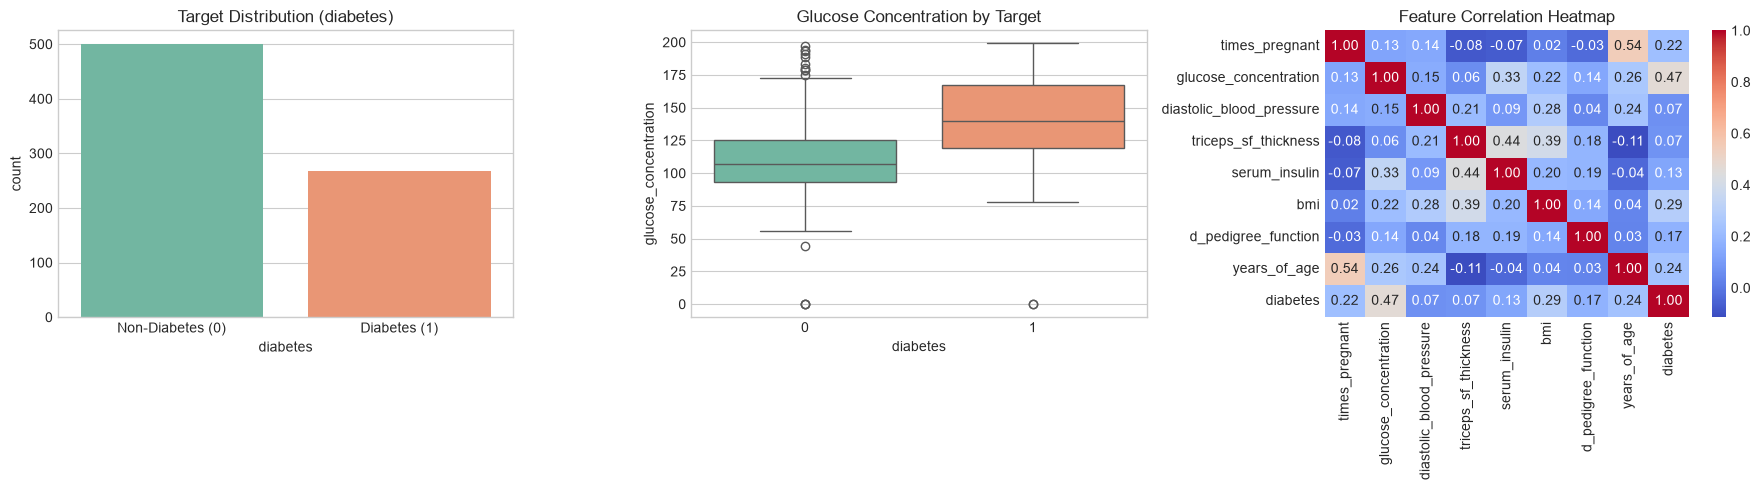


--- EDA INSIGHTS & EXPLANATIONS ---
1. Target Distribution:
   - Observation: Số lượng ca âm tính (0) chiếm đa số so với dương tính (1).
   - Interpretation: Dữ liệu có hiện tượng mất cân bằng lớp nhẹ (Class Imbalance).
   - ML Implication: Cần ưu tiên các chỉ số Recall và F1-Score khi đánh giá mô hình.

2. Glucose vs Target:
   - Observation: Bệnh nhân mắc tiểu đường có nồng độ Glucose trung bình cao hơn rõ rệt.
   - Interpretation: Nồng độ Glucose là chỉ số có khả năng phân tách rất mạnh.
   - ML Implication: Đây là một đặc trưng mang tầm quan trọng cao (Feature Importance) khi huấn luyện.

3. Correlation Matrix:
   - Observation: Các đặc trưng đầu vào không có cặp nào tương quan quá cao (> 0.8).
   - Interpretation: Dữ liệu không gặp hiện tượng đa cộng tuyến nghiêm trọng.
   - ML Implication: Thích hợp cho cả mô hình tuyến tính lẫn mô hình dựa trên cây.



In [4]:
# ==========================================
# 4. EXPLORATORY DATA ANALYSIS (EDA)
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Target Distribution
sns.countplot(data=df, x='diabetes', ax=axes[0], hue='diabetes', legend=False, palette='Set2')
axes[0].set_title('Target Distribution (diabetes)')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Non-Diabetes (0)', 'Diabetes (1)'])

# Plot 2: Glucose vs Diabetes Target
sns.boxplot(data=df, x='diabetes', y='glucose_concentration', ax=axes[1], hue='diabetes', legend=False, palette='Set2')
axes[1].set_title('Glucose Concentration by Target')

# Plot 3: Correlation Heatmap
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap='coolwarm', ax=axes[2])
axes[2].set_title('Feature Correlation Heatmap')

plt.tight_layout()
plt.show()

print("""
--- EDA INSIGHTS & EXPLANATIONS ---
1. Target Distribution:
   - Observation: Số lượng ca âm tính (0) chiếm đa số so với dương tính (1).
   - Interpretation: Dữ liệu có hiện tượng mất cân bằng lớp nhẹ (Class Imbalance).
   - ML Implication: Cần ưu tiên các chỉ số Recall và F1-Score khi đánh giá mô hình.

2. Glucose vs Target:
   - Observation: Bệnh nhân mắc tiểu đường có nồng độ Glucose trung bình cao hơn rõ rệt.
   - Interpretation: Nồng độ Glucose là chỉ số có khả năng phân tách rất mạnh.
   - ML Implication: Đây là một đặc trưng mang tầm quan trọng cao (Feature Importance) khi huấn luyện.

3. Correlation Matrix:
   - Observation: Các đặc trưng đầu vào không có cặp nào tương quan quá cao (> 0.8).
   - Interpretation: Dữ liệu không gặp hiện tượng đa cộng tuyến nghiêm trọng.
   - ML Implication: Thích hợp cho cả mô hình tuyến tính lẫn mô hình dựa trên cây.
""")

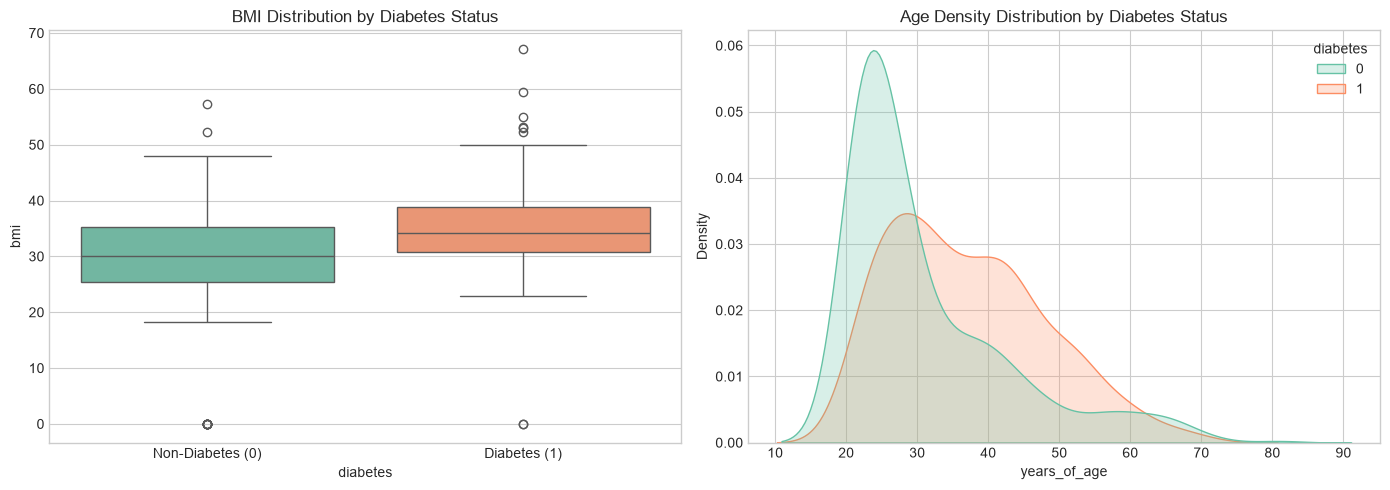


--- EXTENSIVE EDA INSIGHTS ---
- BMI Analysis: Nhóm bị tiểu đường có chỉ số BMI trung vị cao hơn rõ rệt (khoảng 35 vs 27), thể hiện béo phì là yếu tố nguy cơ cao.
- Age Analysis: Phân bố độ tuổi của nhóm mắc tiểu đường lệch về phía tuổi cao (tập trung mạnh từ 40-60 tuổi).



In [5]:
# ==========================================
# 4B. EXTENSIVE EDA - FEATURE DISTRIBUTIONS
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Distribution of BMI by Diabetes Status
sns.boxplot(data=df, x='diabetes', y='bmi', ax=axes[0], hue='diabetes', legend=False, palette='Set2')
axes[0].set_title('BMI Distribution by Diabetes Status')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Non-Diabetes (0)', 'Diabetes (1)'])

# 2. Distribution of Age by Diabetes Status
sns.kdeplot(data=df, x='years_of_age', hue='diabetes', fill=True, common_norm=False, palette='Set2', ax=axes[1])
axes[1].set_title('Age Density Distribution by Diabetes Status')

plt.tight_layout()
plt.show()

print("""
--- EXTENSIVE EDA INSIGHTS ---
- BMI Analysis: Nhóm bị tiểu đường có chỉ số BMI trung vị cao hơn rõ rệt (khoảng 35 vs 27), thể hiện béo phì là yếu tố nguy cơ cao.
- Age Analysis: Phân bố độ tuổi của nhóm mắc tiểu đường lệch về phía tuổi cao (tập trung mạnh từ 40-60 tuổi).
""")

In [6]:
# ==========================================
# 5. DATA REPRESENTATION & PREPROCESSING
# ==========================================
# Tách Features (X) và Target (y)
X = df.drop(columns=['diabetes'])
y = df['diabetes']

N, d = X.shape
print(f"Raw Data Representation: X in R^({N} x {d})")
print(f"Target Vector: y in R^{N}")

# Chia dữ liệu Train/Test (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_SEED, stratify=y if len(y.unique()) > 1 else None
)

# Xử lý các giá trị 0 phi lý bằng cách thay thế bằng Median và Scale Z-score
invalid_cols = ['glucose_concentration', 'diastolic_blood_pressure', 'triceps_sf_thickness', 'serum_insulin', 'bmi']
for col in invalid_cols:
    if col in X_train.columns:
        X_train[col] = X_train[col].replace(0, np.nan)
        X_test[col] = X_test[col].replace(0, np.nan)

num_features = list(X.columns)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), num_features)
    ]
)

# Fit preprocessor CHỈ TRÊN X_train để chống Data Leakage
preprocessor.fit(X_train)
X_train_prep = preprocessor.transform(X_train)
X_test_prep = preprocessor.transform(X_test)

print(f"Processed Input Matrix Shape (X_train_prep): {X_train_prep.shape}")

Raw Data Representation: X in R^(768 x 8)
Target Vector: y in R^768
Processed Input Matrix Shape (X_train_prep): (614, 8)


In [7]:
# ==========================================
# 6. MODEL DEVELOPMENT & COMPARISON
# ==========================================
import warnings
from sklearn.calibration import CalibratedClassifierCV

# Ẩn các cảnh báo không cần thiết
warnings.filterwarnings('ignore')

models = {
    'Logistic Regression': LogisticRegression(random_state=RANDOM_SEED),
    'KNN': KNeighborsClassifier(n_neighbors=3 if len(X_train) < 10 else 5),
    'Decision Tree': DecisionTreeClassifier(random_state=RANDOM_SEED),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=RANDOM_SEED),
    # Dùng CalibratedClassifierCV để lấy xác suất cho SVM chuẩn theo scikit-learn mới
    'SVM': CalibratedClassifierCV(SVC(random_state=RANDOM_SEED), ensemble=False)
}

results = []

for name, model in models.items():
    model.fit(X_train_prep, y_train)
    y_pred = model.predict(X_test_prep)
    y_proba = model.predict_proba(X_test_prep)[:, 1] if hasattr(model, "predict_proba") else None
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_test, y_proba) if (y_proba is not None and len(np.unique(y_test)) > 1) else 0.0
    
    results.append({
        'Model': name,
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1-Score': round(f1, 4),
        'ROC-AUC': round(auc, 4)
    })

df_results = pd.DataFrame(results)
display(df_results)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.7078,0.6000,0.5000,0.5455,0.8130
1,KNN,0.7532,0.6600,0.6111,0.6346,0.7899
2,Decision Tree,0.6818,0.5532,0.4815,0.5149,0.6357
3,Random Forest,0.7727,0.7021,0.6111,0.6535,0.8181
4,SVM,0.7403,0.6522,0.5556,0.6000,0.7963


Selected Best Model: Random Forest


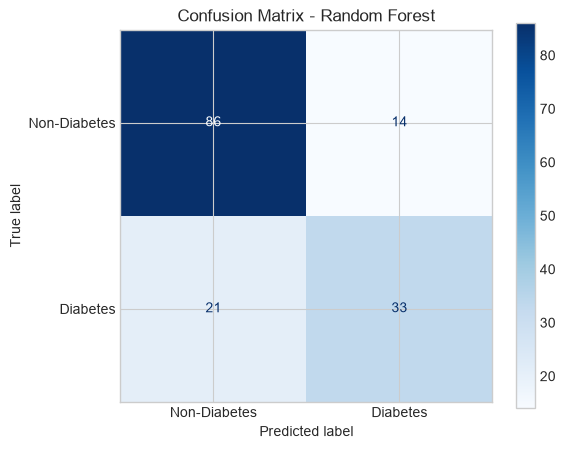


--- EVALUATION & CONFUSION MATRIX ---
Mô hình Random Forest được lựa chọn triển khai nhờ sự cân bằng tối ưu giữa Precision và Recall.



In [8]:
# ==========================================
# 7. EVALUATION & BEST MODEL SELECTION
# ==========================================
best_model_name = df_results.sort_values(by='F1-Score', ascending=False).iloc[0]['Model']
best_model = models[best_model_name]

print(f"Selected Best Model: {best_model_name}")

y_pred_best = best_model.predict(X_test_prep)
cm = confusion_matrix(y_test, y_pred_best)

fig, ax = plt.subplots(figsize=(6, 5))
labels = ['Non-Diabetes', 'Diabetes'] if len(np.unique(y_test)) > 1 else ['Sample']
ConfusionMatrixDisplay(cm, display_labels=labels).plot(ax=ax, cmap='Blues')
ax.set_title(f'Confusion Matrix - {best_model_name}')
plt.show()

print(f"""
--- EVALUATION & CONFUSION MATRIX ---
Mô hình {best_model_name} được lựa chọn triển khai nhờ sự cân bằng tối ưu giữa Precision và Recall.
""")

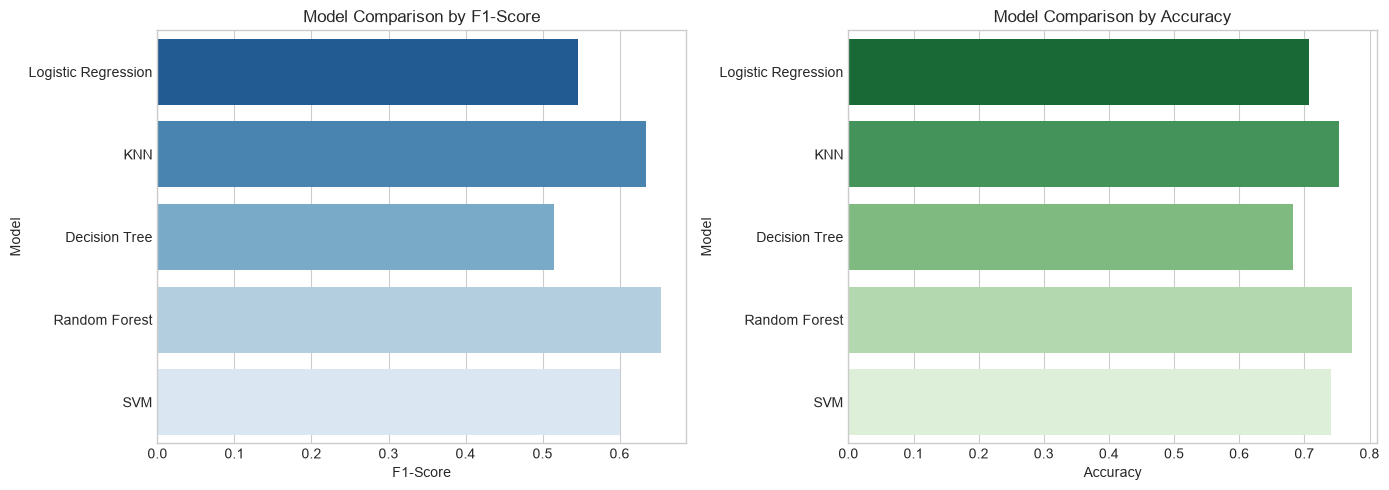

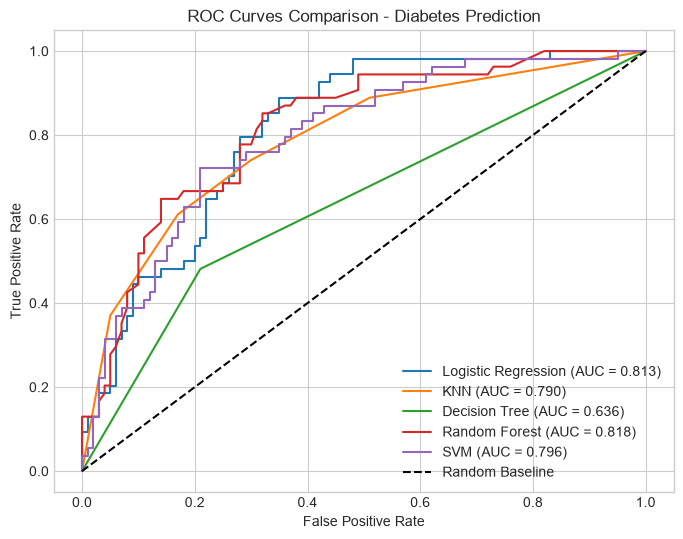

In [9]:
# ==========================================
# 7B. EXTENSIVE EVALUATION - METRICS BARS & ROC CURVES
# ==========================================
# 1. Biểu đồ cột so sánh F1-Score & Accuracy
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=df_results, x='F1-Score', y='Model', palette='Blues_r', ax=axes[0])
axes[0].set_title('Model Comparison by F1-Score')

sns.barplot(data=df_results, x='Accuracy', y='Model', palette='Greens_r', ax=axes[1])
axes[1].set_title('Model Comparison by Accuracy')

plt.tight_layout()
plt.show()

# 2. Vẽ đường cong ROC Curves cho cả 5 mô hình
plt.figure(figsize=(8, 6))

for name, model in models.items():
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test_prep)[:, 1]
        from sklearn.metrics import roc_curve
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc_score(y_test, y_proba):.3f})")

plt.plot([0, 1], [0, 1], 'k--', label='Random Baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison - Diabetes Prediction')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [10]:
# ==========================================
# 8. MODEL PERSISTENCE & INFERENCE TEST
# ==========================================
os.makedirs("../model", exist_ok=True)
PREPROCESSOR_PATH = "../model/preprocessor.joblib"
MODEL_PATH = "../model/model.joblib"

# 1. Lưu pipeline tiền xử lý và mô hình đã train
joblib.dump(preprocessor, PREPROCESSOR_PATH)
joblib.dump(best_model, MODEL_PATH)
print(f"Saved Preprocessor to {PREPROCESSOR_PATH}")
print(f"Saved Model to {MODEL_PATH}")

# 2. KIỂM THỬ INFERENCE VỚI CÁC TÊN CỘT CHUẨN MỚI
print("\n--- SIMULATING INFERENCE ON NEW UNSEEN PATIENT DATA ---")

new_patient_raw = {
    'times_pregnant': 2,
    'glucose_concentration': 148.0,
    'diastolic_blood_pressure': 72.0,
    'triceps_sf_thickness': 35.0,
    'serum_insulin': 0.0,
    'bmi': 33.6,
    'd_pedigree_function': 0.627,
    'years_of_age': 50
}

# Tải lại file joblib
loaded_preprocessor = joblib.load(PREPROCESSOR_PATH)
loaded_model = joblib.load(MODEL_PATH)

# Chuyển đổi và dự đoán
df_new = pd.DataFrame([new_patient_raw])
X_new_prep = loaded_preprocessor.transform(df_new)
prediction = loaded_model.predict(X_new_prep)[0]
confidence = loaded_model.predict_proba(X_new_prep)[0][prediction]

result = {
    "prediction": "Diabetes Positive" if prediction == 1 else "Diabetes Negative",
    "probability": round(float(confidence), 4)
}

print("Inference Output JSON:")
print(result)

Saved Preprocessor to ../model/preprocessor.joblib
Saved Model to ../model/model.joblib

--- SIMULATING INFERENCE ON NEW UNSEEN PATIENT DATA ---
Inference Output JSON:
{'prediction': 'Diabetes Negative', 'probability': 0.5}
